# Fuzzy-marker-based Interactive segmentation with hierarchies

This notebook demonstrates the use of fuzzy markers for interactive image segmentation. The method and the algorithm to compute it in linear time are described in:

    Gabriel Barbosa da Fonseca, Benjamin Perret, Romain Negrel, Jean Cousty, and Silvio Jamil Ferzoli Guimaraes. 
    Fuzzy-marker-based segmentation using hierarchies. IAPR International Conference on Discrete Geometry and Mathematical Morphology (DGMM) 2021.

The user provides an *object* and a *background* marker and the algorithm constructs a segmentation. When providing markers, the user can select the marker location, size and membership degree of the marker. The membership degree values range from 0 to 1, with 1 meaning a marker with a *stronger* influence on the segmentation.

**Warning: This notebook requires ``%matplotlib widgt`` and won't work in evironment that doesn't support it (eg. Google Colab)**

In [1]:
#%%capture
#!pip install higra

In [2]:
import numpy as np
import imageio
%matplotlib widget
import matplotlib.pyplot as plt
from skimage.transform import resize
import cv2
import higra as hg
from ipywidgets import interact, interactive
import ipywidgets as widgets

try:
    from utils import * # imshow, locate_resource, get_sed_model_file
except: # we are probably running from the cloud, try to fetch utils functions from URL
    import urllib.request as request; exec(request.urlopen('https://github.com/higra/Higra-Notebooks/raw/master/utils.py').read(), globals())

Reading image and computing gradient

In [13]:
image = imageio.imread("./data/3063.ppm")
size = image.shape
# we reduce the image size a bit to fit on small screens...
image = resize(image, (int(size[0]*0.2), int(size[1]*0.2)), mode="reflect")
image = image.astype(np.float32) 
size = image.shape[:2]
# gradient computation

detector = cv2.ximgproc.createStructuredEdgeDetection(get_sed_model_file())
gradient_image = detector.detectEdges(image)

# add alpha channel to image for visualisation
image_alpha = np.pad(image, ((0,0),(0,0),(0,1)), mode='constant', constant_values=1) 

/var/folders/zw/kn3b6kb51179q62qtfhpk2900000gn/T/ipykernel_92560/3050123956.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread("./data/3063.ppm")


Computing the hierarchy

In [14]:
graph = hg.get_4_adjacency_graph(size)
edge_weights = hg.weight_graph(graph, gradient_image, hg.WeightFunction.mean)
tree, altitudes = hg.watershed_hierarchy_by_area(graph, edge_weights, canonize_tree=False)
altitudes += 1

In [15]:
# we construct a sketch of the saliency map just for illustration
sm = hg.graph_4_adjacency_2_khalimsky(graph, hg.saliency(tree, altitudes))**0.5
sm = sm[1::2,1::2]
sm = np.pad(sm, ((0,1),(0,1)), mode='edge')
sm = 1 - sm / np.max(sm)
sm = np.dstack([sm]*3)
#alpha channel
sm = np.pad(sm, ((0,0),(0,0),(0,1)), mode='constant', constant_values=1)

# this will be the background of the user interaction area : image | saliency map
base_image = np.hstack((image_alpha, sm))
# markers will store the user provided information: 
# first channel (red) corresponds to background
# second channel (green) corresponds to foreground
markers = np.zeros_like(image_alpha)

Widgets for adjusting marker size and membership degree

In [16]:
#creating widget for selecting membership degree and marker size
def f(Membership,Marker_Size):
    return Membership, Marker_Size

marker_bar = widgets.interactive(f, Membership=(0.0,1.0,0.01),Marker_Size=(1,10));

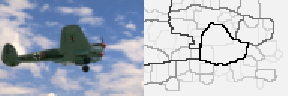

In [17]:
# we will make this figure interactive soon
fig, ax = imshow(base_image)

In [18]:
display(marker_bar);

interactive(children=(FloatSlider(value=0.5, description='Membership', max=1.0, step=0.01), IntSlider(value=5,…

Functions for computing the fuzzy connection values and fuzzy-marker-based segmentation

In [19]:
def fuzzy_connection_values(tree, altitudes, marker, alpha=lambda x: 1 / (x + 1e-9)):
    """
    Computes the fuzzy connection value from any leaf node of the hierarchy to the fuzzy marker in linear time.
    
    :param tree: input tree (must be a binary tree)
    :param altitudes: node altitudes of the input tree
    :param marker: leaf node marker values
    :param alpha: decreasing function from [0, 1] to [1, infinity[ such that alpha(0) > max(altitudes)
    :return: fuzzy connection values of the leaf nodes to the marker
    """

    # transform marker with alpha and compute min in each region
    alpha_marker = alpha(marker)
    min_alpha_marker = hg.accumulate_sequential(tree, alpha_marker, hg.Accumulators.min)
    
    # compute max(mu) for each region
    max_mu = hg.accumulate_sequential(tree, marker.astype(np.float64), hg.Accumulators.max)

    sibling = hg.attribute_sibling(tree)
    parents = tree.parents()

    # fuzzy connection value to sibling: max_alpha(mu(sibling(n))) * (1 - mu(sibling(n)) + altitudes(parent(n)))
    cv_to_sib = min_alpha_marker[sibling] * (1 - max_mu[sibling] + altitudes[parents])

    # recursion
    
    # initial value
    cv_to_sib[-1] = alpha(0) * (1 + altitudes[-1]) 
    
    #T(V \ n) = min ( T( parent(n)), cv_to_sib(n) )
    regional_connection_values = hg.propagate_sequential_and_accumulate(tree, cv_to_sib, hg.Accumulators.min)

    # Fuzzy connection values on the leaves
    # Ch(n,marker) = min(T(n), alpha_marker(n)(1 - mu(n)))
    fuzzy_connection_values = np.minimum(regional_connection_values[:tree.num_leaves()], alpha_marker * (1 - marker))
    
    return fuzzy_connection_values


def fuzzy_marker_based_segmentation(tree, altitudes, object_marker, background_marker):
    """
    Computes the fuzzy-marker-based segmentation of a n image with respect to a fuzzy object marker 
    and a fuzzy background marker.
    
    :param tree: input tree (must be a binary tree)
    :param altitudes: node altitudes of the input tree
    :param object_marker: leaf node object marker values
    :param background_marker: leaf node background marker 
    :return: binary semgnetation of the leaf nodes (1 if the pixel belongs to the object and 0 otherwise)
    
    """
    # Inputs: 'tree' a BPT tree of a given hierarchy
    #         'obj_func': array with size = tree.num_leaves() with values between 0 and 1 for the object 
    #         'bg_func': array with size = tree.num_leaves() with values between 0 and 1 for the background
    #         'shape': Width x Height shape to return a label matrix.
    # Outputs: 'result': array with size = tree.num_leaves() with 0 for background and 1 for object
    #          'labeled_mat': reshaped 'result' with shape = 'shape'
    
    result = np.zeros(tree.num_leaves())
    
    fuzzy_connection_value_to_object = fuzzy_connection_values(tree, altitudes, object_marker)
    fuzzy_connection_value_to_background = fuzzy_connection_values(tree, altitudes, background_marker)
    
    #computing the segmentation using the fuzzy connection values
    segmentation = (fuzzy_connection_value_to_object < fuzzy_connection_value_to_background)
    return segmentation

In [20]:
# Define a callback function that will update the drawing

def onclick(event):
    #remove prvious drawing
    ax.clear()
    
    # click position
    x = int(event.xdata) % size[1] # modulo click on the right image wraps on the first one
    y = int(event.ydata)
    marker_conf = marker_bar.result[0]
    marker_size = marker_bar.result[1]
    if event.button == 1: # left click
        markers[y-marker_size:y+marker_size, x-marker_size:x+marker_size, :]= (0, marker_conf, 0, 1) # green marker : object
    elif event.button == 3: # right click
        markers[y-marker_size:y+marker_size, x-marker_size:x+marker_size, :]= (marker_conf, 0, 0, 1) # red marker : background
    
    # compute binary segmentation from the two markers
    # Marker = RGBA --> W,H,RGBA
    # So, [:,:,0] = R, [:,:,1] = G
    object_marker = markers[:,:,1].reshape(tree.num_leaves())
    background_marker = markers[:,:,0].reshape(tree.num_leaves())
    segmentation = fuzzy_marker_based_segmentation(tree,altitudes, object_marker, background_marker)
    segmentation = segmentation.reshape(markers.shape[0:2])
    
    # redraw background
    ax.imshow(base_image, interpolation='none')
    
    # use the binary segmentation as the alpha channel to display the result
    tmp = np.copy(image)
    res = np.dstack((tmp, segmentation))
    
    # show markers on left image
    op = np.hstack((markers, res))
    ax.imshow(op, interpolation='none')
    

# Create a hard reference to the callback not to be cleared by the garbage collector
fig.canvas.mpl_connect('button_press_event', onclick)

16

In [24]:
markers[:,:,1]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(64, 96), dtype=float32)

## FMBS por força bruta e contagem de empates

As células abaixo apresentam uma **implementação experimental por força bruta**
do algoritmo Fuzzy Marker-Based Segmentation (FMBS). Diferentemente da
implementação eficiente baseada em hierarquia utilizada acima, esta versão
calcula explicitamente os valores de conexão fuzzy entre os pixels e os
marcadores individuais. Isso permite analisar e contar os casos em que
diferentes marcadores produzem o mesmo valor ótimo de conexão fuzzy
(**empates**).

### Como executar

Antes de executar as células abaixo, **execute todas as células do notebook
original acima**, incluindo a célula de segmentação interativa.

Na imagem interativa:

1. Adicione pelo menos um **marcador de objeto**.
2. Adicione pelo menos um **marcador de fundo**.
3. Certifique-se de que os marcadores foram corretamente definidos antes de
   continuar.

A implementação por força bruta abaixo utiliza a imagem, a hierarquia e os
marcadores definidos durante essa etapa interativa. Portanto, executar essas
células sem antes definir os marcadores poderá resultar em erros ou resultados
inválidos.

> **Observação sobre desempenho:** o tamanho da imagem utilizada neste notebook
> foi significativamente reduzido, pois a implementação por força bruta possui
> um custo computacional elevado. Diferentemente da versão eficiente do FMBS,
> esta implementação avalia explicitamente as conexões com os marcadores
> individuais e, portanto, pode se tornar muito lenta para imagens maiores ou
> para conjuntos com muitos marcadores.

### TODO

- [ ] **Verificar a implementação por força bruta.** O código abaixo foi
      desenvolvido com auxílio de uma ferramenta de IA e deve ser cuidadosamente
      revisado para confirmar se o cálculo da conexão fuzzy entre cada pixel e
      cada marcador está matematicamente de acordo com a formulação original do
      FMBS.
- [ ] Comparar os valores de conexão fuzzy obtidos pela versão por força bruta
      com os valores produzidos pela implementação eficiente do FMBS.
- [ ] Criar exemplos controlados contendo empates conhecidos e verificar se o
      procedimento de contagem identifica corretamente esses casos.
- [ ] Analisar a quantidade e a distribuição dos empates para os marcadores de
      objeto e de fundo.

In [21]:
"""
Versão mais simples para contar os empates
"""


def lowest_common_ancestor(tree, x, y):
    """
    Finds the lowest common ancestor (LCA) of two nodes.

    This implementation is intentionally simple and does not use
    Higra's optimized LCA routines.
    """
    parents = tree.parents()

    # Ancestors of x
    ancestors_x = set()

    node = x
    while True:
        ancestors_x.add(node)

        parent = parents[node]

        if parent == node:
            break

        node = parent

    # Walk from y toward the root until reaching an ancestor of x
    node = y

    while node not in ancestors_x:
        node = parents[node]

    return node


def pairwise_fuzzy_connection_value(
    tree,
    altitudes,
    marker,
    x,
    m,
    alpha=lambda x: 1 / (x + 1e-9)
):
    """
    Computes the fuzzy connection value between a pixel x and
    a particular marker pixel m.

    Parameters
    ----------
    tree : hg.Tree
        Hierarchical tree.

    altitudes : ndarray
        Altitudes of the tree nodes.

    marker : ndarray
        Fuzzy marker memberships on the leaves.

    x : int
        Leaf corresponding to the pixel.

    m : int
        Leaf corresponding to the marker pixel.

    alpha : callable
        Marker transformation.

    Returns
    -------
    float
        Connection value between x and marker pixel m.
    """

    mu_m = marker[m]

    # Same pixel
    if x == m:
        return alpha(mu_m) * (1 - mu_m)

    # Find the smallest region containing x and m
    lca = lowest_common_ancestor(tree, x, m)

    # Pairwise fuzzy connection
    return alpha(mu_m) * (
        1 - mu_m + altitudes[lca]
    )


def fuzzy_connection_values_bruteforce(
    tree,
    altitudes,
    marker,
    alpha=lambda x: 1 / (x + 1e-9),
    return_matrix=False
):
    """
    Brute-force computation of fuzzy connection values.

    Explicitly computes the connection from every pixel x to
    every non-zero marker pixel m.

    Parameters
    ----------
    tree : hg.Tree
        Hierarchical tree.

    altitudes : ndarray
        Altitudes of the tree nodes.

    marker : ndarray
        Fuzzy marker memberships.

    alpha : callable
        Marker transformation.

    return_matrix : bool
        If True, also returns the complete pixel x marker
        connection matrix.

    Returns
    -------
    fcv : ndarray
        Minimum connection value for every pixel.

    tie_count : ndarray
        Number of marker pixels attaining that minimum.

    marker_indices : ndarray
        Indices of the marker pixels.

    connections : ndarray, optional
        Complete pixel x marker connection matrix.
    """

    n_leaves = tree.num_leaves()

    # We consider every non-zero marker membership to be
    # an actual marker pixel.
    marker_indices = np.flatnonzero(marker > 0)

    if len(marker_indices) == 0:
        raise ValueError("The marker contains no non-zero pixels.")

    n_markers = len(marker_indices)

    # rows    -> pixels x
    # columns -> marker pixels m
    connections = np.empty(
        (n_leaves, n_markers),
        dtype=np.float64
    )

    # ---------------------------------------------------------
    # Compute C(x, m) explicitly for every pair
    # ---------------------------------------------------------

    for x in range(n_leaves):

        for j, m in enumerate(marker_indices):

            connections[x, j] = pairwise_fuzzy_connection_value(
                tree,
                altitudes,
                marker,
                x,
                m,
                alpha
            )

    # ---------------------------------------------------------
    # Connection to the fuzzy marker:
    #
    #       C(x, M) = min_m C(x, m)
    # ---------------------------------------------------------

    fcv = np.min(connections, axis=1)

    # ---------------------------------------------------------
    # Number of marker pixels attaining that minimum
    # ---------------------------------------------------------

    tie_count = np.sum(
        connections == fcv[:, None],
        axis=1
    )

    if return_matrix:
        return (
            fcv,
            tie_count,
            marker_indices,
            connections
        )
        

    return fcv, tie_count

In [22]:
def fuzzy_marker_based_segmentation_bruteforce(
    tree,
    altitudes,
    object_marker,
    background_marker,
    alpha=lambda x: 1 / (x + 1e-9)
):
    """
    Brute-force FMBS with tie counting.
    """

    object_fcv, object_ties = fuzzy_connection_values_bruteforce(
        tree,
        altitudes,
        object_marker,
        alpha
    )

    background_fcv, background_ties = fuzzy_connection_values_bruteforce(
        tree,
        altitudes,
        background_marker,
        alpha
    )

    segmentation = object_fcv < background_fcv

    return (
        segmentation,
        object_fcv,
        background_fcv,
        object_ties,
        background_ties
    )

In [23]:
object_marker = markers[:,:,1].reshape(tree.num_leaves())
background_marker = markers[:,:,0].reshape(tree.num_leaves())

(
    segmentation,
    object_fcv,
    background_fcv,
    object_ties,
    background_ties
) = fuzzy_marker_based_segmentation_bruteforce(
    tree,
    altitudes,
    object_marker,
    background_marker
)

KeyboardInterrupt: 

In [ ]:
total_object_ties = np.sum(object_ties - 1)
total_background_ties = np.sum(background_ties - 1)

total_ties = total_object_ties + total_background_ties

print("Object ties:", total_object_ties)
print("Background ties:", total_background_ties)
print("Total ties:", total_ties)

16